<a href="https://colab.research.google.com/github/asiddiqha/ai-workbench/blob/main/K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# K-Means Clustering
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
X, y = make_blobs(n_samples=1000, n_features=2, centers=4, random_state=42)

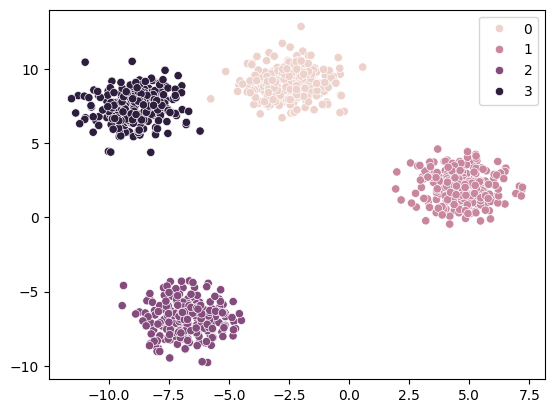

In [3]:
# visualize
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)
plt.show()

In [4]:
# K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X) # Cluster Number

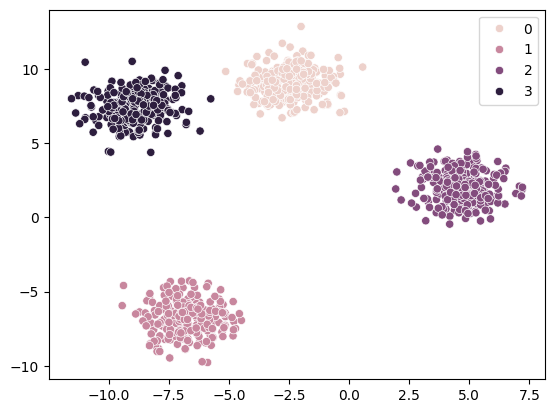

In [7]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels)
plt.show()

In [8]:
# Choose k value (Elbow method and Silhouette score)

wcss = []
for k in range(1, 21):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

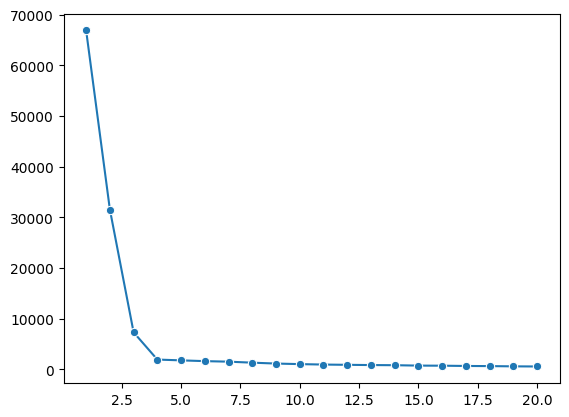

In [11]:
sns.lineplot(x=range(1, 21), y=wcss, marker='o')
plt.show()

In [12]:
# Kneed Module
!pip install kneed

In [13]:
from kneed import KneeLocator
kl = KneeLocator(range(1, 21), wcss, curve='convex', direction='decreasing')
print("Optimal k = ", kl.elbow)

Optimal k =  4


In [14]:
# Silhouette Score

from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2, 21):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

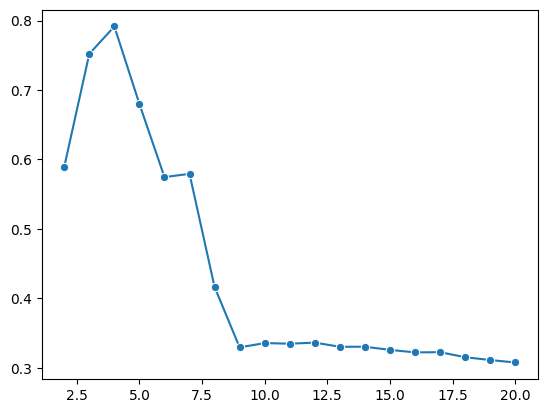

In [15]:
# Plot - k and ss
sns.lineplot(x=range(2, 21), y=silhouette_scores, marker='o')
plt.show()